In [12]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from tqdm import tqdm  
import pickle

In [2]:
sample_rate = 22050
duration = 3  
samples= sample_rate * duration

n_mfcc = 40
n_mels = 128
max_frames = 130

emotions = ['neutral','happy','sad','angry','fearful','disgust']
emotion_to_int={emotion: idx for idx, emotion in enumerate(emotions)}
int_to_emotion={idx: emotion for idx, emotion in enumerate(emotions)}


In [3]:
df = pd.read_csv('../data/dataset.csv')
df.head()

,filepath,emotion,source
0,../data/raw/ravdess/Actor_16/03-01-05-01-02-01...,angry,ravdess
1,../data/raw/ravdess/Actor_16/03-01-06-01-02-02...,fearful,ravdess
2,../data/raw/ravdess/Actor_16/03-01-06-02-01-02...,fearful,ravdess
3,../data/raw/ravdess/Actor_16/03-01-05-02-01-01...,angry,ravdess
4,../data/raw/ravdess/Actor_16/03-01-07-01-01-01...,disgust,ravdess


In [5]:

def extract_features_single(filepath, sample_rate=sample_rate,duration=duration, n_mfcc=n_mfcc,
                            n_mels=n_mels, max_frames=max_frames):
    audio, sr = librosa.load(
        filepath,
        sr=sample_rate,
        duration=duration,
        res_type='soxr_hq'
    )
    if len(audio) <samples:
        audio = np.pad(audio,(0,samples- len(audio)),mode='constant')
    else:
        audio = audio[:samples]
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=n_mfcc    
    )
    mel=librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels  
    )

    mel = librosa.power_to_db(mel, ref=np.max)
    mfcc = (mfcc - np.mean(mfcc, axis=0)) / (np.std(mfcc, axis=0) + 1e-6)
    mel = (mel - np.mean(mel)) / (np.std(mel) + 1e-6)
    
    if mfcc.shape[1] < max_frames:
        mfcc = np.pad(mfcc, ((0,0), (0, max_frames - mfcc.shape[1])))
    else:
        mfcc = mfcc[:, :max_frames]
    
    if mel.shape[1] < max_frames:
        mel = np.pad(mel, ((0,0), (0, max_frames - mel.shape[1])))
    else:
        mel = mel[:, :max_frames]
    
    mfcc = mfcc.T 
    return mfcc, mel

sample_path = df.iloc[0]['filepath']
sample_emotion = df.iloc[0]['emotion']

mfcc_test, mel_test = extract_features_single(sample_path)

print(f"✅ Feature extraction works!")
print(f"\nTest file: {os.path.basename(sample_path)}")
print(f"Emotion: {sample_emotion}")
print(f"\nOutput shapes:")
print(f"  MFCC shape : {mfcc_test.shape}  ← (time_steps, n_mfcc) for LSTM")
print(f"  Mel shape  : {mel_test.shape} ← (n_mels, time_frames) for CNN")
print(f"\nMFCC value range: {mfcc_test.min():.2f} to {mfcc_test.max():.2f}")
print(f"Mel value range : {mel_test.min():.2f} to {mel_test.max():.2f}")

✅ Feature extraction works!

Test file: 03-01-05-01-02-01-16.wav
Emotion: angry

Output shapes:
  MFCC shape : (130, 40)  ← (time_steps, n_mfcc) for LSTM
  Mel shape  : (128, 130) ← (n_mels, time_frames) for CNN

MFCC value range: -6.24 to 3.59
Mel value range : -1.03 to 2.92


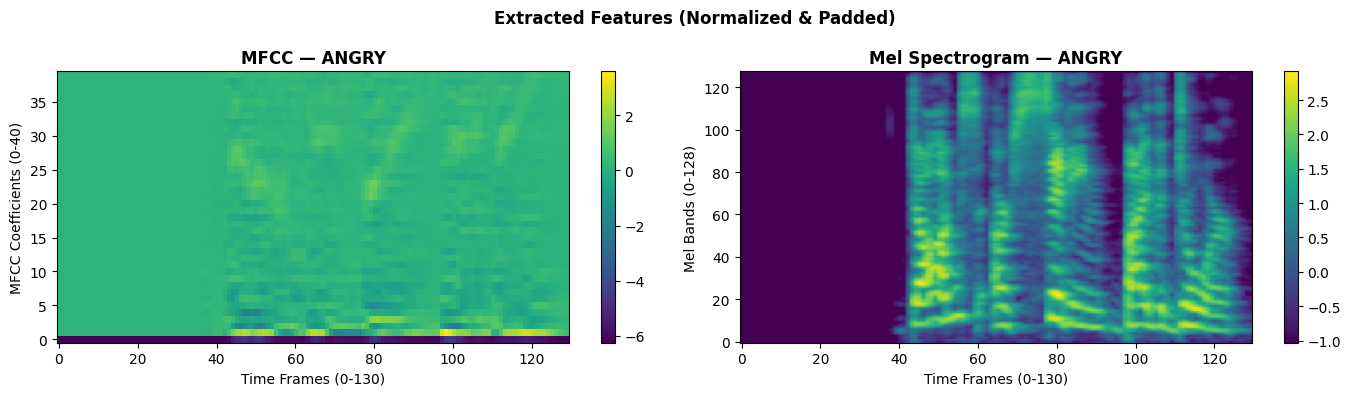

Both features have fixed shapes — ready for model input!


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im1 = axes[0].imshow(
    mfcc_test.T,          
    aspect='auto',        
    origin='lower',      
    cmap='viridis'        
)
axes[0].set_title(f'MFCC — {sample_emotion.upper()}', fontweight='bold')
axes[0].set_xlabel('Time Frames (0-130)')
axes[0].set_ylabel('MFCC Coefficients (0-40)')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(
    mel_test,
    aspect='auto',
    origin='lower',
    cmap='viridis'
)
axes[1].set_title(f'Mel Spectrogram — {sample_emotion.upper()}', fontweight='bold')
axes[1].set_xlabel('Time Frames (0-130)')
axes[1].set_ylabel('Mel Bands (0-128)')
plt.colorbar(im2, ax=axes[1])

plt.suptitle('Extracted Features (Normalized & Padded)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Both features have fixed shapes — ready for model input!")

In [10]:
all_mfcc = []    
all_mel  = []    
all_labels = [] 
failed_files = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting features"):
    try:
    
        mfcc, mel = extract_features_single(row['filepath'])
       
        label = emotion_to_int[row['emotion']]
        
        all_mfcc.append(mfcc)
        all_mel.append(mel)
        all_labels.append(label)
        
    except Exception as e:
    
        failed_files.append({
            'filepath': row['filepath'],
            'error': str(e)
        })

all_mfcc   = np.array(all_mfcc)   
all_mel    = np.array(all_mel)     
all_labels = np.array(all_labels) 

print(f"\n✅ Feature extraction complete!")
print(f"\nArray shapes:")
print(f"  MFCC   : {all_mfcc.shape}  ← (samples, time_steps, features)")
print(f"  Mel    : {all_mel.shape} ← (samples, mel_bands, time_frames)")
print(f"  Labels : {all_labels.shape}  ← (samples,)")
print(f"\nSuccessfully processed : {len(all_mfcc)} files")
print(f"Failed files           : {len(failed_files)}")

if failed_files:
    print("\nFailed files:")
    for f in failed_files[:5]: 
        print(f"  {f['filepath']}: {f['error']}")

Extracting features: 100%|██████████| 14774/14774 [01:38<00:00, 150.71it/s]



✅ Feature extraction complete!

Array shapes:
  MFCC   : (14774, 130, 40)  ← (samples, time_steps, features)
  Mel    : (14774, 128, 130) ← (samples, mel_bands, time_frames)
  Labels : (14774,)  ← (samples,)

Successfully processed : 14774 files
Failed files           : 0


In [13]:
os.makedirs('../data/processed', exist_ok=True)
np.save('../data/processed/mfcc_features.npy', all_mfcc)
np.save('../data/processed/mel_features.npy',  all_mel)
np.save('../data/processed/labels.npy',        all_labels)

with open('../data/processed/emotion_mappings.pkl', 'wb') as f:
    pickle.dump({
        'emotion_to_int': emotion_to_int,
        'int_to_emotion': int_to_emotion,
        'emotions': emotions
    }, f)

print("All features saved!")
print(f"\nSaved files:")
print(f"  mfcc_features.npy — {all_mfcc.nbytes / 1024 / 1024:.1f} MB")
print(f"  mel_features.npy  — {all_mel.nbytes / 1024 / 1024:.1f} MB")
print(f"  labels.npy        — {all_labels.nbytes / 1024:.1f} KB")
print(f"  emotion_mappings.pkl")

All features saved!

Saved files:
  mfcc_features.npy — 293.1 MB
  mel_features.npy  — 937.8 MB
  labels.npy        — 115.4 KB
  emotion_mappings.pkl
